# Implémentation de l'algorithme DMRG (1 site)

In [669]:
import numpy as np
import scipy as sc
import copy
import matplotlib.pyplot as plt

### Initialisation du MPS:

On initialise l'algorithme en tirant un MPS formé de N tenseurs aléatoires avec d le nombres de paramètre physiques et chi la bond dimension du MPS).
Le premier tenseur (extrémité gauche) est de taille (d,chi), les 
tenseurs centraux sont de taille (chi,d,chi), le dernier tenseur (extrémité droite) est de taille (chi,d) (voir schéma)

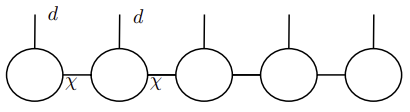

In [672]:
# Initialisation:

N = 4 # Longueur du MPS
d = 2 # dimension physique
chi = 5 # Bond dimension




def initialization(N,d,chi):
    """
    Input: N longueur du MPS, d dimension physique, chi bond dimension
    Output: MPS aléatoire de longueur N, de dimension physique d, bond dimension chi
    """
    np.random.seed(2)  # Set a fixed seed for NumPy
    A = [] # liste contenant le MPS 

    #Convention: on numérote initialement les tenseurs dans le sens anti trigo, en partant de la branche à gauche

    #Ajout du premier tenseur (rang 2)
    A.append(np.random.rand(d,chi))

    #Ajout des tenseurs "centraux" (rang 3)
    for _ in range(N-2):
        A.append(np.random.rand(chi,d,chi))

    #Ajout du dernier tenseur (rang 2)
    A.append(np.random.rand(chi,d))

    return A


A = initialization(N,d,chi)



## Codage de l'opérateur sous la forme d'un MPO

Afin de pouvoir appliquer un opérateur au MPS, il va falloir le représenter sous la forme d'un MPO. De la même manière que pour les MPS, les MPO seront représentés comme une liste d'array numpy. 

Les tenseurs ont les tailles suivantes:
 - $(\chi,d,\chi)$ pour le premier tenseur (extrémité gauche)
 - $(\chi,d,\chi,d)$ pour les tenseurs centraux
 - $(d,\chi,\chi)$ pour le dernier tenseur (extrémité droite)

**Remarque:** La bond dimension du MPO notée $\chi$ est indépendante de la bond dimension du MPS, celles-ci peuvent très bien être différentes




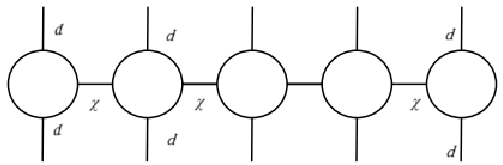

Le codage d'un opérateur sous sa forme MPO se fait de la manière suivante:

Nous allons d'abord écrire les fonctions qui permettent de décomposer un hamiltonien sous forme d'un MPO. Pour cela, nous considérerons un opérateur $\hat{H}$ qu'on suppose être une somme de produits d'opérateurs de Pauli.

Considérons par exemple le cas $N=4$ (4 sites)

Pour obtenir la forme $\hat{H} = \sum_{i} C_{i}\hat{S}_{1}\hat{S}_{2}\hat{S}_{3}\hat{S}_{4}$ (où $C_{i}$ est un coefficient complexe, $\hat{S}_{k}$ est un opérateur de Pauli associé au $k$-ième site) à partir de $\hat{H}$ quelconque, on utilise la décomposition de Jordan-Wigner qui nous donne le hamiltonien décomposé en somme de produits d'opérateurs de Pauli. Les MPO associés aux produits correspondent simplement aux produits des matrices de Pauli.

Enfin, pour obtenir la représentation MPO de $\hat{H}$, on additionnera successivement les représentations MPO des produits de matrices de Pauli.


Les matrices de Pauli sont les suivantes:

In [678]:
#Définition des matrices de Pauli
Sx=np.array([[0,1],[1,0]], dtype="complex_")
Sy=np.array([[0,-1j],[1j,0]], dtype="complex_")
Sz=np.array([[1,0],[0,-1]], dtype="complex_")
I2=np.array([[1,0],[0,1]], dtype="complex_")

In [680]:
Splus=0.5*(Sx+1j*Sy)
Sminus=0.5*(Sx-1j*Sy)

On encode ensuite les opérateurs de Pauli (à un site) sous la forme de tenseurs. Celle-ci correspond simplement à la matrice de Pauli associée (bond dimension $\chi=1$)

In [683]:
#Opérateur de Pauli Sx

#Tenseur central
Hx=np.zeros((1,2,1,2),dtype="complex_")
Hx[0,:,0,:]=Sx

#Premier tenseur (extrémité gauche)
Hxg=np.zeros((2,1,2),dtype="complex_")
Hxg[:,0,:]=Sx

#Dernier tenseur (extrémité droite)
Hxd=np.zeros((1,2,2),dtype="complex_")
Hxd[0,:,:]=Sx

In [685]:
#Opérateur de Pauli Sy

#Tenseur central
Hy=np.zeros((1,2,1,2),dtype="complex_")
Hy[0,:,0,:]=Sy

#Premier tenseur (extrémité gauche)
Hyg=np.zeros((2,1,2),dtype="complex_")
Hyg[:,0,:]=Sy

#Dernier tenseur (extrémité droite)
Hyd=np.zeros((1,2,2),dtype="complex_")
Hyd[0,:,:]=Sy

In [687]:
#Opérateur de Pauli Sz

#Tenseur central
Hz=np.zeros((1,2,1,2), dtype="complex_")
Hz[0,:,0,:]=Sz

#Premier tenseur (extrémité gauche)
Hzg=np.zeros((2,1,2),dtype="complex_")
Hzg[:,0,:]=Sz

#Dernier tenseur (extrémité droite)
Hzd=np.zeros((1,2,2),dtype="complex_")
Hzd[0,:,:]=Sz

In [689]:
#Opérateur identité

#Tenseur central
H2=np.zeros((1,2,1,2),dtype="complex_")
H2[0,:,0,:]=I2

#Premier tenseur (extrémité gauche)
H2g=np.zeros((2,1,2),dtype="complex_")
H2g[:,0,:]=I2

#Dernier tenseur (extrémité droite)
H2d=np.zeros((1,2,2),dtype="complex_")
H2d[0,:,:]=I2

### Somme de deux MPO

In [692]:

# prend deux MPO A et B en entrée (de même longueur) et renvoie le MPO correspondant à la somme de A et B
# Rq: les MPO sont supposés du même format que précedemment

def MPO_sum(A,B):
    """
    Input: A,B deux MPO de même longueur n (listes d'arrays correspondant aux tenseurs du MPO) 
    Sortie: renvoie le MPO A+B (de longueur n) (liste d'arrays)

    """
    n = len(A)
    chi_A = A[0].shape[1]
    chi_B = B[0].shape[1]
    chi_S = chi_A + chi_B
    S = []

    #Ajout du premier tenseur
    S_i = np.zeros((d,chi_S,d), dtype="complex_")
    for sigma1 in range(d):
        for sigma2 in range(d):

            for k in range(chi_A):
                S_i[sigma1,k,sigma2] = A[0][sigma1,k,sigma2]

            for k in range(chi_B):
                S_i[sigma1,k+chi_A,sigma2] = B[0][sigma1,k,sigma2]
            
    S.append(S_i)

    #Ajout des tenseurs "centraux"
    for i in range(1,n-1):
        S_i = np.zeros((chi_S,d,chi_S,d), dtype="complex_")
        for sigma1 in range(d):
            for sigma2 in range(d):
                
                for k in range(chi_A):
                    for l in range(chi_A):
                        S_i[k,sigma1,l,sigma2] = A[i][k,sigma1,l,sigma2]

                for k in range(chi_B):
                    for l in range(chi_B):
                        S_i[chi_A + k,sigma1,chi_A + l,sigma2] = B[i][k,sigma1,l,sigma2]      
        S.append(S_i)

    #Ajout du dernier tenseur
    S_i = np.zeros((chi_S,d,d), dtype="complex_")
    for sigma1 in range(d):
        for sigma2 in range(d):

            for k in range(chi_A):
                S_i[k,sigma1,sigma2] = A[n-1][k,sigma1,sigma2]

            for k in range(chi_B):
                S_i[k+chi_A,sigma1,sigma2] = B[n-1][k,sigma1,sigma2]
    S.append(S_i)
    
    
    return S


In [694]:
def pauli_to_MPO(H): #H est un hamiltonien donné sous forme d'une somme de produits de tenseurs de Pauli. Ici H est représenté sous forme de tableau où les termes en d'indice i dans la somme sont à la ième ligne
    """
    Input: H hamiltonien (somme de produits d'opérateurs de Pauli) sous la forme d'un tableau dont la i-ème ligne contient les termes du i-ème produit de la somme
    Output: renvoie le MPO M associé à H (liste d'arrays)

    On calcule le MPO associée somme des produits de Pauli pour obtenir la représentation MPO de H
    """
    M=H[0]
    for i in range(len(H)-1):
        M=MPO_sum(M,H[i+1])
    return M

Grâce à la décomposition de Jordan-Wigner, on obtient la décomposition suivante pour le hamiltonien d'Anderson à 4 sites

In [697]:
H1=[[0.25*H2g,H2,H2,H2d],
            [0.25*Hzg,Hz,H2,H2d],
            [0.25*Hzg,H2,H2,H2d],
            [0.25*H2g,Hz,H2,H2d],
            [0.5*Hxg,Hz,Hx,H2d],
            [0.5*Hyg,Hz,Hy,H2d],
            [0.5*H2g,Hx,Hz,Hxd],
            [0.5*H2g,Hy,Hz,Hyd],
            [-0.5*H2g,H2,Hz,H2d],
            [-0.5*H2g,H2,H2,Hzd]]

In [699]:
H=pauli_to_MPO(H1)
H1 = H

In [701]:
Hid=[H2g,H2,H2,H2d]
H_diag=[H2g,H2,Hx,H2d]

## Orthonormalisation du MPS

Dans cette partie, on va définir les fonctions permettant d'orthonormaliser (à droite ou à gauche) le MPS. En effet, l'algorithme DMRG nécessite de manipuler des MPS vérifiant certaines propriétés d'orthogonalité à droite ou à gauche (cf. rapport)

Le procédé d'orthonormalisation s'effectue par décompositions QR (ou RQ selon le cas) successives sur les tenseurs du MPS. La procédure complète est expliquée avec plus de détails dans le rapport 

**Remarque**: Les bond dimensions des tenseurs du MPS orthonormalisé restent inférieures ou égales à $\chi$

In [708]:

def MPS_orth_left(A): #Normalise le MPS à gauche en effectuant des décompositions QR successives
    """
    Input: MPS A de longueur N (liste de N arrays)
    Output: MPS M correspondant à la forme orthonormalisée à gauche de A (liste de N arrays)
    """
    M = copy.deepcopy(A)

    #Traitement du premier tenseur
    q,r = sc.linalg.qr(M[0], mode = "economic") #décomposition QR du premier tenseur
    M[0] = q # M[0] <- q
    M[1] = np.tensordot(r,M[1], axes = ([1],[0])) #On contracte r au tenseur suivant (2nd tenseur) afin de réitérer la procédure

    
    #Traitement des tenseurs centraux
    for i in range(1,N-1): #On ne s'occupe pas du dernier tenseur
        p=np.shape(M[i])[0] # correspond à la bond dimension à gauche du i-ème tenseur
        M[i] = np.reshape(M[i],(d*p,chi)) #reshape du i-ème tenseur afin de pouvoir appliquer la décomposition QR
        q,r = sc.linalg.qr(M[i], mode = "economic") # décomposition QR
        M[i] = np.reshape(q,(np.shape(q)[0]//d,d,np.shape(q)[1])) # M[i] <- q (après reshape de q afin d'obtenir un tenseur de rang 3)
        M[i+1] = np.tensordot(r,M[i+1], axes = ([1],[0])) #on contracte r au tenseur suivant afin de réitérer la procédure


    return M

#L'orthonormalisation à droite s'effectue de la même manière en balayant de droite à gauche, et en effectuant une décomposition RQ (au lieu de QR)
def MPS_orth_right(A):
    """
    Input: MPS A de longueur N (liste de N arrays)
    Output: MPS M correspondant à la forme orthonormalisée à droite de A (liste de N arrays)
    """

    M = copy.deepcopy(A)
    
    r,q = sc.linalg.rq(M[N-1],mode = "economic")
    M[N-1]=q
    M[N-2] = np.tensordot(M[N-2],r,axes = ([2],[0]))
    

    for i in range(N-2,0,-1): #On ne s'occupe pas du premier tenseur
        M[i]=np.reshape(M[i],(chi,d*np.shape(M[i])[2]))
        r,q = sc.linalg.rq(M[i], mode = "economic")
        M[i] = np.reshape(q,(np.shape(q)[0],d,np.shape(q)[1]//d))
        M[i-1] = np.tensordot(M[i-1],r,1)

    
    return M

print(MPS_orth_right(A))

[array([[ -0.12081342,   0.32495321,   0.85384583,   0.38743753,
        -18.80429972],
       [ -0.0915352 ,   0.29491921,   0.86773745,   0.36695126,
        -16.31786458]]), array([[[-2.61194372e-01, -5.83726566e-01,  2.62430251e-01,
          1.33357056e-02],
        [-2.41026045e-01,  5.92498232e-01, -3.35329158e-01,
         -1.99991425e-02]],

       [[-1.79841540e-01, -4.35073162e-01, -6.34328587e-01,
         -2.81067232e-01],
        [-2.05013284e-01, -4.91118732e-02,  4.35452062e-01,
          2.50870281e-01]],

       [[ 4.28274811e-02,  6.12713903e-02, -3.83829820e-02,
         -4.90020059e-01],
        [-2.51713707e-02, -2.46813921e-01, -6.39256771e-01,
          5.31619020e-01]],

       [[-2.01122120e-02, -1.73284000e-01, -5.34215391e-01,
          4.75132447e-01],
        [-5.18348132e-02, -2.78651654e-01, -5.17128112e-01,
         -3.32680254e-01]],

       [[ 7.79199215e-03,  2.72362033e-02, -7.09271221e-02,
         -6.72799728e-01],
        [-4.12327490e-04,  3.357

In [710]:
M = MPS_orth_right(A)

def test_norm_right(A):
    T = np.tensordot(A[N-1],A[N-1].conj().T, axes = ([1],[0]))
    print(A[N-4].shape)
    print(A[N-4].conj().T.shape)
    T_aux =  np.tensordot(A[N-4],A[N-4].conj().T, axes = ([0],[1]))

    print(T_aux)  

test_norm_right(M)

(2, 5)
(5, 2)
[[ 2.29745752e-02 -6.62541974e-02 -1.82584555e-01 -8.03966104e-02
   3.76547075e+00]
 [-6.62541974e-02  1.92571929e-01  5.33372385e-01  2.34120046e-01
  -1.09229693e+01]
 [-1.82584555e-01  5.33372385e-01  1.48202098e+00  6.49229274e-01
  -3.02155951e+01]
 [-8.03966104e-02  2.34120046e-01  6.49229274e-01  2.84761071e-01
  -1.32733525e+01]
 [ 3.76547075e+00 -1.09229693e+01 -3.02155951e+01 -1.32733525e+01
   6.19874392e+02]]


**Remarque:** En pratique, on n'utilisera que l'orthonormalisation à droite dans la mise en pratique de l'algorithme.

## Opérations de contractions et tenseurs auxiliaires

Dans cette partie, nous définirons les tenseurs auxiliaires et les fonctions de contractions utilisés dans l'algorithme. Ils serviront au calcul de l'opérateur à diagonaliser lors de l'exécution de l'algorithme.

Une des étapes de l'algorithme DMRG consiste en effet à diagonaliser le tenseur suivant (où i varie entre $0$ et $N-1$) 



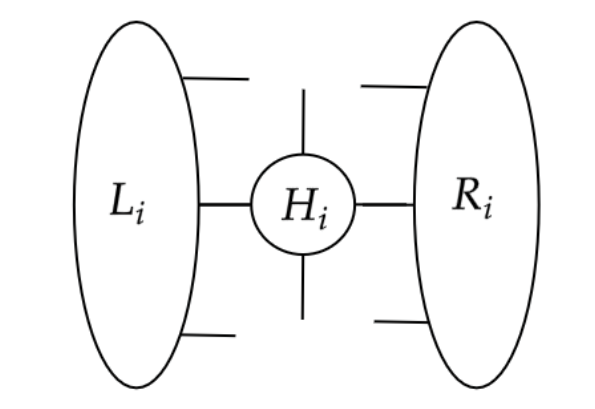

(où $L_i$ correspond à la contraction des tenseurs $M_k$, $H_k$, $M^{\dagger}_k$ pour $k<i$ et $R_i$ correspond à la contraction des tenseurs $M_k$, $H_k$, $M^{\dagger}_k$ pour $k>i$

Les fonctions suivantes permettent de calculer successivement les tenseurs $L_i$ et $R_i$ à partir du MPS et du MPO. 

**Remarque:** Pour les indices i=0 (resp. N-1) aux extrémités, on ne considère que $R_i$ (resp $L_i$)  

Les entrées de la fonction right_contraction sont les tenseurs décrits par le schéma suivant.

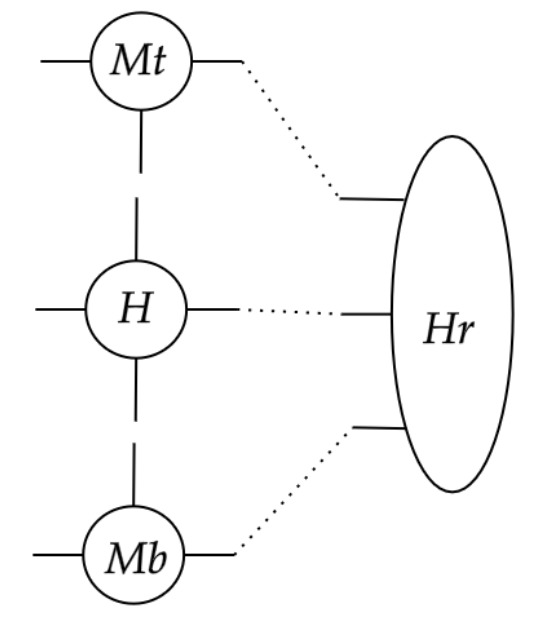

De même, la fonction left_contraction est décrite par le schéma ci-dessous

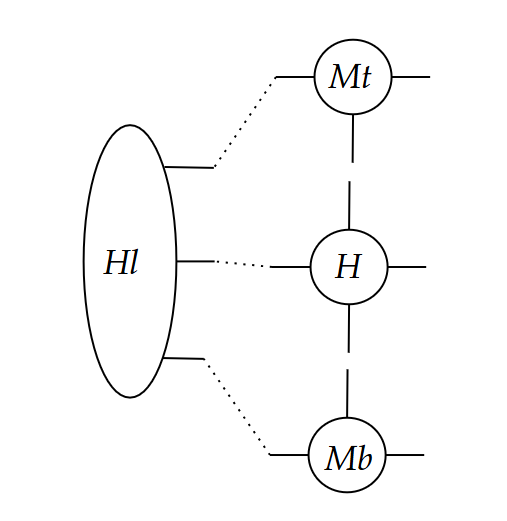

In [719]:

def right_contraction(Hr, Mt, Mb, H):
    """
    Input: tenseurs Hr, Mt, Mb, H (voir premier schéma)
    Output: renvoie le tenseur résultant de la contraction de ces quatres tenseurs (voir schéma)
    """
    Taux = np.tensordot(Hr,Mb, axes = ([2],[2]))
    Taux = np.tensordot(Taux,H, axes = ([3,0],[3,2]))
    Taux = np.tensordot(Taux,Mt, axes = ([0,3],[0,1]))
    Taux = np.transpose(Taux,(1,2,0))  #ordre final: de bas en haut: 2,0,1 (sens horaire en partant du milieu)

    return Taux

def left_contraction(Hl,Mt,Mb,H):
    """
    Input: tenseurs Hl, Mt, Mb, H (voir schéma ci-dessus)
    Output: renvoie le tenseur résultant de la contraction de ces quatres tenseurs (voir schéma)
    """

    Taux = np.tensordot(Hl,Mb, axes = ([2],[0]))
    Taux = np.tensordot(Taux,H, axes = ([1,2],[0,3]))
    Taux = np.tensordot(Taux,Mt, axes = ([0,2],[2,1]))
    Taux = np.transpose(Taux,(2,1,0)) #ordre final: de haut en bas: 0, 1, 2

    return Taux


**Remarque:** Dans l'algorithme, on appellera la fonction avec les arguments $Mt = M^\dagger_k$, $Mb = M_k$, $Hr = R_k$

Au cours de l'algorithme, il est utile de garder ces tenseurs en mémoire: on va les stocker dans les listes R et L (qui seront ensuite mise à jour au fil des balayages). Afin de procéder au premier balayage, on va calculer R. Pour cela, on commence par calculer R[N-2] (extrémité droite), puis on calcule successivement R[N-3],...,R[0] grâce à la fonction right_contraction définie précedemment. 

In [724]:

#Calcul de R[i], composante à droite de la matrice effective (Rq: on ne calcule pas R[0] ici)

R = [0 for _ in range(N)] #liste contenant les R_i
L = [0 for _ in range(N)] #liste contenant les L_i

#Calcul de R[N-2] par contraction de H[N-1], A[N-1] et son transconjugué
Taux = np.tensordot(H[N-1],A[N-1], axes = ([2],[1]))
Taux = np.tensordot(Taux,A[N-1].conj().T, axes = ([1],[0]))
R[N-2] = np.transpose(Taux,(0,2,1))
print(R[N-2].shape)

#Calcul de L[1], de la même manière
Taux = np.tensordot(H[0],A[0], axes = ([2],[0]))
Taux = np.tensordot(Taux,A[0].conj().T, axes = ([0],[1]))
L[1] = np.transpose(Taux,(2,0,1))
print(L[1].shape)

#Calcul de la liste R
for i in range(N-3,-1,-1):
    R[i] = right_contraction(R[i+1],A[i+1].conj().T,A[i+1],H[i+1])



(10, 5, 5)
(5, 10, 5)


A partir des tenseurs $L_i$ ,$R_i$ et $H_i$ on peut ensuite assembler le tenseur à diagonaliser, puis à le réindexer pour obtenir une matrice qui pourra être diagonalisée.

In [727]:
print(L[1].shape)
print(R[1].shape)

def effective_Matrix(L,R,H): #Calcule la matrice effective à diagonaliser
        """
        Input: tenseur L,R,H décrit par les schémas précédents
        Output: renvoie la matrice effective à diagonaliser ainsi qu'un tuple gardant en mémoire la forme du tenseur
        """
        #On calcule d'abord le tenseur à diagonaliser en contractant L,R et H
        Meff = np.tensordot(L,H,axes = ([1],[0]))
        Meff = np.tensordot(Meff,R, axes = ([3],[0]))
        Meff = np.transpose(Meff, (0,2,4,1,3,5))

        #On reshape ce tenseur afin d'obtenir une matrice
        t=np.shape(Meff)
        Meff = np.reshape(Meff,(t[0]*t[1]*t[2],t[3]*t[4]*t[5]))
        return Meff,t

print(effective_Matrix(L[1],R[1],H[1]))
    

(5, 10, 5)
(10, 5, 5)
(array([[ 2.36309111e+00+0.j,  2.06821759e+00+0.j,  2.27783791e+00+0.j,
        ...,  1.79879257e-01+0.j,  1.28296923e-01+0.j,
         4.65520846e-01+0.j],
       [ 2.06821759e+00+0.j,  1.82800046e+00+0.j,  2.01737374e+00+0.j,
        ..., -2.17692109e-03+0.j, -5.38169520e-02+0.j,
         1.90529328e-01+0.j],
       [ 2.27783791e+00+0.j,  2.01737374e+00+0.j,  2.22112989e+00+0.j,
        ..., -9.03223518e-03+0.j, -6.45478168e-02+0.j,
         1.94712458e-01+0.j],
       ...,
       [ 1.79879257e-01+0.j, -2.17692109e-03+0.j, -9.03223518e-03+0.j,
        ..., -6.20932554e-01+0.j, -5.20735086e-01+0.j,
        -9.20097644e-01+0.j],
       [ 1.28296923e-01+0.j, -5.38169520e-02+0.j, -6.45478168e-02+0.j,
        ..., -5.20735086e-01+0.j, -3.32733705e-01+0.j,
        -8.01354261e-01+0.j],
       [ 4.65520846e-01+0.j,  1.90529328e-01+0.j,  1.94712458e-01+0.j,
        ..., -9.20097644e-01+0.j, -8.01354261e-01+0.j,
        -1.34708565e+00+0.j]]), (5, 2, 5, 5, 2, 5))


In [729]:
def valeur_moyenne(H,A):
    """
    Input: MPO H, MPS A
    Output: renvoie la valeur moyenne de H pour l'état M
    """
    N = len(H)
    M = copy.deepcopy(A)
    
    Taux = np.tensordot(H[N-1],M[N-1], axes = ([2],[1]))
    Taux = np.tensordot(Taux,M[N-1].conj().T, axes = ([1],[0]))
    Raux = np.transpose(Taux,(0,2,1))

    for i in range(N-3,-1,-1):
        Raux = right_contraction(Raux,M[i+1].conj().T,M[i+1],H[i+1])

    Taux = np.tensordot(H[0],M[0], axes = ([2],[0]))
    Taux = np.tensordot(Taux,M[0].conj().T, axes = ([0],[1]))
    Taux = np.transpose(Taux,(2,0,1))

    Res = np.tensordot(Taux,Raux, axes = ([0,1,2],[1,0,2]))
    return Res

    

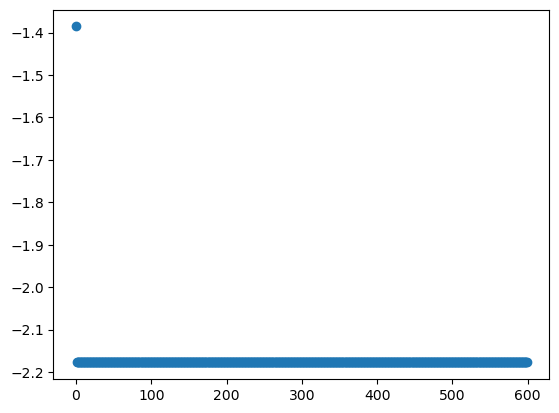

In [782]:
def DMRG(Np,N,d,chi):
    """
    Input: nombre de balayages (aller-retour) Np, paramètres du système N,d,chi
    Output: liste contenant les valeurs approchées de l'énergie la plus basse, MPS final
    """
    E = [] #liste des énergies

    #Création d'un MPS A orthonormalisé à droite
    A = initialization(N,d,chi)
    A = MPS_orth_right(A)

    
    R = [0 for _ in range(N)] #liste contenant les R_i
    L = [0 for _ in range(N)] #liste contenant les L_i
    
    #Calcul de R[N-2] par contraction de H[N-1], A[N-1] et son transconjugué
    Taux1 = np.tensordot(H[N-1],A[N-1], axes = ([2],[1]))
    Taux1 = np.tensordot(Taux1,A[N-1].conj().T, axes = ([1],[0]))
    R[N-2] = np.transpose(Taux1,(0,2,1))

    #Calcul des R[i]
    for i in range(N-3,-1,-1):
        R[i] = right_contraction(R[i+1],A[i+1].conj().T,A[i+1],H[i+1])

    #Balayages
    for _ in range(Np):
       
        #Balayage de gauche à droite
       
        #Traitement du 1er tenseur (cas de bord: les dimensions de A[0] sont différentes)

        Meff = np.tensordot(H[0],R[0],axes = ([1],[0]))
        Meff = np.transpose(Meff, (0,2,1,3))
        t=np.shape(Meff)
        Meff = np.reshape(Meff, (t[0]*t[1],t[2]*t[3]))
        
        # Diagonalisation (Lanczos)
        #val,vec = sc.sparse.linalg.eigsh(Meff, k=1, which='SA', v0=A[0]) 
        eigenvalues,eigenvec = np.linalg.eigh(Meff)
        val = eigenvalues[0]
        vec = eigenvec[:,0] 
        vec = vec/ np.linalg.norm(vec)
        vec = np.reshape(vec,(t[2],t[3]))
        #E.append("gauche")
        E.append(val)
        

        #Décomposition SVD sur la matrice obtenue
        U,s,V = sc.linalg.svd(vec,full_matrices = False)
        S = np.diag(s)
        V = np.matmul(S,V)

        # Mise à jour des tenseurs A[0] et A[1]
        
        A[0] = U.copy()
        A[1] = np.tensordot(V,A[1],1)

        #Calcul de L[1] 

        Taux2 = np.tensordot(H[0],A[0], axes = ([2],[0]))
        Taux2 = np.tensordot(Taux2,A[0].conj().T, axes = ([0],[1]))
        L[1] = np.transpose(Taux2,(2,0,1))

        #print(valeur_moyenne(H,A))
        

        
        
        for i in range(1,N-1): #balayage de gauche à droite (pour les tenseurs centraux)
            Meff,t = effective_Matrix(L[i],R[i],H[i])
            
            # Diagonalisation (Lanczos)
            #val,vec = sc.sparse.linalg.eigsh(Meff, k=1, which='SA', v0=A[i])
            eigenvalues,eigenvec = np.linalg.eigh(Meff)
            val = eigenvalues[0]
            vec = eigenvec[:,0] 
            vec = vec/ np.linalg.norm(vec)
            vec = np.reshape(vec,(t[3]*t[4],t[5]))
            E.append(val)

            #Décomposition SVD sur la matrice obtenue
            U,s,V = sc.linalg.svd(vec,full_matrices = False)
            S = np.diag(s)
            V = np.matmul(S,V)
        
            # Mise à jour des tenseurs A[i] et A[i+1]
            A[i] = np.reshape(U,(t[3],t[4],t[5]))
            A[i+1] = np.tensordot(V,A[i+1],1)

            #Calcul de L[i] 
            L[i+1] = left_contraction(L[i],A[i].conj().T,A[i],H[i])

            #print(valeur_moyenne(H,A))

        

        #Traitement du dernier tenseur


        #Balayage de droite à gauche
        
        #Traitement du dernier tenseur
        
        Meff = np.tensordot(L[N-1],H[N-1],axes = ([1],[0]))
        Meff = np.transpose(Meff, (0,2,1,3))
        t=np.shape(Meff)
        Meff = np.reshape(Meff, (t[0]*t[1],t[2]*t[3]))

    

        # Diagonalisation (Lanczos)
        #val,vec = sc.sparse.linalg.eigsh(Meff, k=1, which='SA', v0=A[N-1]) 
        eigenvalues, eigenvec = np.linalg.eigh(Meff)
        val = eigenvalues[0]
        vec = eigenvec[:,0] 
        vec = vec/ np.linalg.norm(vec)
        vec = np.reshape(vec,(t[2],t[3]))
        #E.append("droite")
        E.append(val)

        # Décomposition SVD sur la matrice obtenue
        U,s,V = sc.linalg.svd(vec,full_matrices = False)
        S = np.diag(s)
        U = np.matmul(U,S)

        # Mise à jour des tenseurs A[N-1] et A[N-2]
        
        A[N-1] = V
        A[N-2] = np.tensordot(A[N-2],U,1)
    

        #Calcul de R[N-2] 
        Taux3 = np.tensordot(H[N-1],A[N-1], axes = ([2],[1]))
        Taux3 = np.tensordot(Taux3,A[N-1].conj().T, axes = ([1],[0]))
        R[N-2] = np.transpose(Taux3,(0,2,1))

        #print(valeur_moyenne(H,A))

        

        for i in range(N-2,0,-1): #balayage de droite à gauche (pour les MPS centraux)
    
            Meff,t = effective_Matrix(L[i],R[i],H[i])
            

            # Diagonalisation (Lanczos)
            #val,vec = sc.sparse.linalg.eigsh(Meff, k=1, which='SA', v0=A[i]) 
            eigenvalues,eigenvec = np.linalg.eigh(Meff)
            val = eigenvalues[0]
            vec = eigenvec[:,0]
            vec = vec/ np.linalg.norm(vec)
            vec = np.reshape(vec,(t[3],t[4]*t[5]))
            E.append(val)
            #E.append(val[0])

            #Décomposition SVD sur la matrice obtenue
            U,s,V = sc.linalg.svd(vec,full_matrices = False)
            S = np.diag(s)
            U = np.matmul(U,S)
        
            # Mise à jour des tenseurs A[i] et A[i+1]
        
            A[i] = np.reshape(V,(t[3],t[4],t[5]))
            A[i-1] = np.tensordot(A[i-1],U,1)

            #Calcul de R[i-1] 
            R[i-1] = right_contraction(R[i],A[i].conj().T,A[i],H[i])
            #print(valeur_moyenne(H,A))
        
        

        #print(valeur_moyenne(copy.deepcopy(H),copy.deepcopy(A)))
        
    return E,A

energies, Mf = DMRG(100,N,d,chi)


indices = list(range(len(energies)))

# Tracé du graphique avec l'index en abscisse
plt.plot(indices, energies, marker = "o",linestyle = "none")



# Afficher le graphique
plt.show()

        

In [784]:
print(valeur_moyenne(H,Mf))

(-2.177409680899285+0j)


In [786]:
print(valeur_moyenne(h,A))

(1243.713441940297+0j)


In [788]:
print(energies[-1])

-2.177409680899285


In [790]:
def overlap(M1,M2):
    """
    Input: MPS M1, MPS M2 of same length
    Output:overlap of M1 and M2 <M1|M2>
    """
    n = len(M1)
    overlap = np.tensordot(M1[0].conj().T,M2[0],axes = ([1],[0]))
    for i in range(1,n-1):
        overlap = np.tensordot(overlap,M2[i],axes = ([1],[0]))
        overlap = np.tensordot(M1[i].conj().T,overlap, axes = ([2,1],[0,1]))
    overlap = np.tensordot(overlap,M2[n-1],axes = ([1],[0]))
    overlap = np.tensordot(overlap,M1[n-1].conj().T,axes = ([1,0],[0,1]))
    return overlap

def simple_MPO_multiplication(H,M):
    """
    Input: MPO H, MPS M de même longueur
    Output: MPS représentant HM
    """
    pass

In [792]:
print(overlap(Mf,Mf))

(1.0000000000000002+0j)
